# 02 · MADE：用掩码把"一个 MLP"变成"一串条件分布"

**前置课程**：01 链式法则与自回归分解。

**回顾上节课遗留问题**：自回归分解 $p(x) = \prod_i p(x_i \mid x_{<i})$ 免掉了配分函数，但逐位调用共享 MLP 要循环 $N$ 次，太慢。我们想要：

> **一次前向**同时输出所有 $N$ 个条件分布 $\{p(x_i \mid x_{<i})\}_{i=1}^N$，并且严格保证第 $i$ 个输出看不到 $x_i, x_{i+1}, \dots$（不偷看未来）。

**本课方案（MADE, Germain et al. 2015）**：不改架构，只"修剪"连接——给权重乘上一个固定的 0/1 掩码矩阵 $M$：

$$W \;\leftarrow\; M \odot W.$$

**类比**：一张**涂黑了"未来答案区"的答题卡**。每个输出单元只能从被允许的输入单元抄答案，未来位置的格子被墨水盖死——想偷看也没有通路。

## 1 · MADE 的三步规则

**第 1 步：给每个变量指定"度数"（即因果序）。** 设 $m(k) \in \{1, \dots, N\}$。自然顺序下 $m(k) = k+1$：变量 0 度数 1、变量 1 度数 2……度数小 = 先生成。MADE 的招牌是允许把度数**随机置换**（第 3 节演示）。

**第 2 步：隐藏层每个单元随机分一个度数** $\in \{1, \dots, N-1\}$。（取到 $N$ 的隐藏单元对任何输出都不可见，纯属浪费参数。）

**第 3 步：连接规则。** 输入单元 $i$ 连到输出单元 $j$，当且仅当

$$m_{\text{in}}(i) < m_{\text{out}}(j).$$

输出层第 $k$ 个单元对应变量 $k$、度数 $m(k)$，于是它只能连到度数**严格小于** $m(k)$ 的输入——恰好是因果序里排在 $k$ 前面的变量；它**自己**（度数相同）被规则禁止，所以不会把 $x_k$ 本身泄露给 $p(x_k \mid x_{<k})$。

形式化：$M_{ij} = \mathbb{1}\!\left[m_{\text{in}}(i) < m_{\text{out}}(j)\right]$，每一层做 $W \leftarrow M \odot W$。

## 2 · 动手实现：MaskedDense（纯 jax，手写前向，不用 flax）

In [1]:
import itertools

import numpy as np
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from matplotlib import font_manager

for font in ["Hiragino Sans GB", "Arial Unicode MS", "Heiti TC", "STHeiti", "Songti SC", "PingFang SC"]:
    if font in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams["font.sans-serif"] = [font]
        print("绘图使用中文字体:", font)
        break
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(1)              # 隐藏层度数的随机性
key = jax.random.PRNGKey(42)   # 权重初始化的随机性
print("jax 版本:", jax.__version__)

绘图使用中文字体: Hiragino Sans GB
jax 版本: 0.9.2


In [2]:
N = 4              # 比特数
HIDDEN = [16, 16]  # 两个隐藏层

def make_degrees(order):
    """因果序 order（一个排列）→ 每个变量的度数。order[0] 最先生成，度数 1。"""
    deg = np.empty(N, dtype=int)
    deg[np.asarray(order)] = np.arange(1, N + 1)
    return deg

def masked_dense(rng, deg_in, deg_out, scale=0.4):
    """一个被掩码修剪的全连接层：
    只保留 deg_in[i] < deg_out[j] 的连接 W[i, j]，其余被掩码置零。"""
    n_in, n_out = len(deg_in), len(deg_out)
    W = jax.random.normal(rng, (n_in, n_out)) * scale
    M = (np.asarray(deg_in)[:, None] < np.asarray(deg_out)[None, :]).astype(np.float32)
    return {"W": jnp.asarray(W), "b": jnp.zeros(n_out), "M": jnp.asarray(M)}

def build_made(rng, hidden_sizes, deg_in):
    """组装 MADE：隐藏层度数在 {1..N-1} 随机分配；输出层第 k 个单元对应变量 k。"""
    layers, prev_deg = [], deg_in
    hidden_deg = np.random.randint(1, N, size=sum(hidden_sizes))   # ∈ {1, ..., N-1}
    pos = 0
    for h in hidden_sizes:
        deg_h = hidden_deg[pos:pos + h]
        rng, sub = jax.random.split(rng)
        layers.append(masked_dense(sub, prev_deg, deg_h))
        prev_deg, pos = deg_h, pos + h
    out = masked_dense(rng, prev_deg, deg_in)      # 输出单元 k ↔ 变量 k（度数 deg_in[k]）
    return {"hidden": layers, "out": out, "deg_in": deg_in}

def made_logits(made, x):
    """x: (..., N)。返回 (..., N)：out[..., i] = logit_i，
    即 p(x_i = 1 | x_{<i}) = sigmoid(logit_i)。前向时现乘掩码，因果性永不被破坏。"""
    h = x
    for layer in made["hidden"]:
        h = jnp.tanh(h @ (layer["M"] * layer["W"]) + layer["b"])
    out = made["out"]
    return h @ (out["M"] * out["W"]) + out["b"]

# 自然因果序：0 → 1 → 2 → 3
order = np.array([0, 1, 2, 3])
deg_in = make_degrees(order)
rng, key = jax.random.split(key)
made = build_made(rng, HIDDEN, deg_in)

n_params = sum(int(l["W"].size + l["b"].size) for l in made["hidden"]) + int(made["out"]["W"].size + made["out"]["b"].size)
print("变量度数 deg_in:", deg_in, "（度数 1 最先生成）")
print("第一层每个隐藏单元可见的输入个数:", np.asarray(made["hidden"][0]["M"].sum(axis=0), dtype=int))
print("MADE 总参数量:", n_params, "（被掩码清零的权重不再携带任何信息）")

变量度数 deg_in: [1 2 3 4] （度数 1 最先生成）
第一层每个隐藏单元可见的输入个数: [1 0 0 1 1 0 0 1 0 1 0 2 1 2 0 2]
MADE 总参数量: 420 （被掩码清零的权重不再携带任何信息）


## 3 · 核心实验：用 Jacobian 检验"不偷看未来"

怎么证明第 $i$ 个输出真的看不到 $x_i$ 及之后的输入？让**自动微分**当裁判：

logit$_i$ 是输入 $x$ 的函数。若掩码结构正确，则对一切 $k \ge i$（含对角线 $k=i$，即不依赖自己）：

$$\frac{\partial\, \mathrm{logit}_i}{\partial x_k} = 0.$$

$N \times N$ 的 Jacobian 矩阵 $J[i,k] = \partial\,\mathrm{logit}_i / \partial x_k$ 就是"信息流"的显微镜——上三角应当**精确为 0**。

Jacobian J[i, k] = ∂logit_i / ∂x_k：
[[ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [-0.0728  0.      0.      0.    ]]

上三角（k ≥ i）|J| 最大值 = 0.00e+00   ← 应为 0：第 i 个输出看不到第 i 位及之后的任何输入


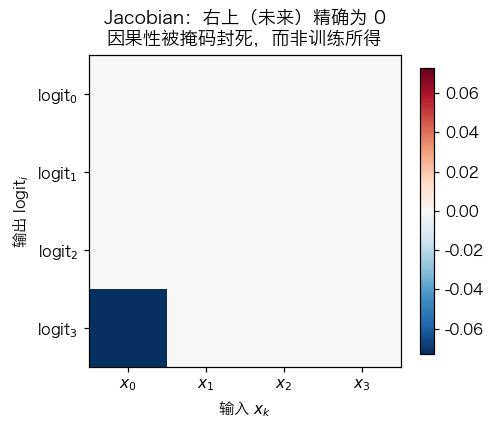

In [3]:
x_probe = jnp.full((N,), 0.3)     # 在任意一点求导（网络对连续输入也有定义，0/1 之外照样可导）
J = np.asarray(jax.jacobian(lambda x: made_logits(made, x))(x_probe))   # J[i, k] = ∂logit_i / ∂x_k

print("Jacobian J[i, k] = ∂logit_i / ∂x_k：")
print(np.round(J, 4))

upper = np.triu_indices(N)        # 所有 k ≥ i 的位置（含对角线）
max_upper = float(np.abs(J[upper]).max())
print(f"\n上三角（k ≥ i）|J| 最大值 = {max_upper:.2e}   ← 应为 0：第 i 个输出看不到第 i 位及之后的任何输入")

# ---------- 可视化 ----------
fig, ax = plt.subplots(figsize=(4.6, 4.0), dpi=110)
im = ax.imshow(J, cmap="RdBu_r", vmin=-np.abs(J).max(), vmax=np.abs(J).max())
ax.set_xticks(range(N)); ax.set_xticklabels([f"$x_{k}$" for k in range(N)])
ax.set_yticks(range(N)); ax.set_yticklabels([f"logit$_{i}$" for i in range(N)])
ax.set_xlabel("输入 $x_k$")
ax.set_ylabel("输出 logit$_i$")
ax.set_title("Jacobian：右上（未来）精确为 0\n因果性被掩码封死，而非训练所得")
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

$J[i,k] \neq 0$ 就意味着 logit$_i$ 的输出会随输入 $x_k$ 变化。矩阵中只有下三角非零（可以看过去），上三角**精确为 0**——不是"训练后趋近于 0"，而是**连接在初始化那一刻就被剪断**，梯度根本无法流过。这就是"用结构保证因果序"的含义。

> 注意：掩码是乘在权重上的常数 0/1 矩阵，之后无论 $W$ 怎么更新，$M \odot W$ 的零模式都不会改变——因果性不会在训练中"退化"。

## 4 · MADE 的招牌：因果序可以是任意置换

谁规定必须从 $x_0$ 接龙到 $x_3$？把度数换成一个随机置换，掩码自动适配新的因果序——Jacobian 的零模式会跟着挪位置，但"输出 $i$ 只依赖因果序里排在前面的变量"这条铁律不变。MADE 训练时甚至每个 epoch 换一次序，让同一架构覆盖更多依赖模式。

In [4]:
order_rand = np.array([2, 0, 3, 1])     # 生成顺序：先 x2，再 x0，再 x3，最后 x1
deg_rand = make_degrees(order_rand)
rng, key = jax.random.split(key)
made_rand = build_made(rng, HIDDEN, deg_rand)

J_rand = np.asarray(jax.jacobian(lambda x: made_logits(made_rand, x))(x_probe))

# 按因果序（度数从小到大）重排行、列，应再次出现"下三角"结构
perm = np.argsort(deg_rand)
J_reordered = J_rand[np.ix_(perm, perm)]
upper = np.triu_indices(N)

print("因果序 [2, 0, 3, 1] 的 Jacobian，按因果序重排行列后：")
print(np.round(J_reordered, 4))
print(f"\n重排后上三角 |J| 最大值 = {float(np.abs(J_reordered[upper]).max()):.2e}   ← 仍精确为 0")
print("结论：因果序是可设计的结构先验，掩码自动适配任意序。")

因果序 [2, 0, 3, 1] 的 Jacobian，按因果序重排行列后：
[[0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.4479 0.     0.     0.    ]]

重排后上三角 |J| 最大值 = 0.00e+00   ← 仍精确为 0
结论：因果序是可设计的结构先验，掩码自动适配任意序。


## 5 · 合法性验证：没训练过的网络，已经是合法分布

现在用这个 MADE（自然序）输出 4-bit 空间全部 $2^4 = 16$ 个构型的条件分布，验证三件事：

1. **联合分布自动归一化**：$\sum_x p(x) = 1$（合法性来自掩码结构，与训练无关）；
2. **输出单元的语义正确**：网络第 $i$ 个输出严格等于 $p(x_i = 1 \mid x_{<i})$——用"从联合分布表中枚举出的条件概率"对照；
3. **与手工目标分布对照**：数值不同（还没训练），但两边都是合法分布。

In [5]:
configs = np.array(list(itertools.product([0, 1], repeat=N)))    # (16, 4)

# 一次批量前向，同时拿到 16 个构型 × 4 个条件 logit
all_logits = made_logits(made, jnp.asarray(configs, dtype=jnp.float32))     # (16, 4)
log_p = jnp.sum(jnp.where(configs == 1,
                          jax.nn.log_sigmoid(all_logits),
                          jax.nn.log_sigmoid(-all_logits)),
                axis=1)
probs = jnp.exp(log_p)

print(f"全空间概率总和 Σ_x p(x) = {float(probs.sum()):.12f}   ← 未训练，自动归一化")
print(f"概率最小值 = {float(probs.min()):.3e} > 0：sigmoid 保证每个条件概率严格为正")

全空间概率总和 Σ_x p(x) = 1.000000000000   ← 未训练，自动归一化
概率最小值 = 6.076e-02 > 0：sigmoid 保证每个条件概率严格为正


In [6]:
def table_conditional(p_table, i, prefix):
    """从联合分布表枚举：p(x_i = 1 | x_{<i} = prefix)"""
    mask_pre = np.all(configs[:, :i] == np.array(prefix), axis=1)
    return float(p_table[mask_pre & (configs[:, i] == 1)].sum() / p_table[mask_pre].sum())

def net_conditional(i, prefix):
    """网络直接前向：前缀填进输入，未生成位补 0 占位（反正掩码保证 logit_i 看不到它们）"""
    x_in = np.zeros(N); x_in[:i] = prefix
    logit_i = made_logits(made, jnp.asarray(x_in, dtype=jnp.float32))[i]
    return float(jax.nn.sigmoid(logit_i))

# 对全部 (i, 前缀) 组合逐一对照
max_err, n_checked = 0.0, 0
print(" i  前缀     表格条件 p(x_i=1|x_<i)   网络输出    偏差")
for i in range(1, N):
    for prefix in itertools.product([0, 1], repeat=i):
        p_tab = table_conditional(probs, i, prefix)
        p_net = net_conditional(i, prefix)
        err = abs(p_tab - p_net)
        max_err, n_checked = max(max_err, err), n_checked + 1
        if n_checked <= 8:
            print(f" {i}  {''.join(map(str, prefix)):<6}    {p_tab:.6f}               {p_net:.6f}    {err:.1e}")
print(f"\n共核对 {n_checked} 个（前缀, 位）组合，最大偏差 = {max_err:.2e}   ← 浮点精度内完全一致")
print("→ 网络第 i 个输出的语义严格就是 p(x_i=1 | x_{<i})：由掩码结构保证，不是巧合。")

 i  前缀     表格条件 p(x_i=1|x_<i)   网络输出    偏差


 1  0         0.500000               0.500000    0.0e+00
 1  1         0.500000               0.500000    0.0e+00
 2  00        0.500000               0.500000    0.0e+00
 2  01        0.500000               0.500000    0.0e+00
 2  10        0.500000               0.500000    0.0e+00
 2  11        0.500000               0.500000    0.0e+00
 3  000       0.500000               0.500000    0.0e+00
 3  001       0.500000               0.500000    0.0e+00

共核对 14 个（前缀, 位）组合，最大偏差 = 0.00e+00   ← 浮点精度内完全一致
→ 网络第 i 个输出的语义严格就是 p(x_i=1 | x_{<i})：由掩码结构保证，不是巧合。


In [7]:
# ---------- 对照一个手工目标分布 p*(x) ∝ exp(f(x))（带位间相互作用）----------
def f_star(x):
    return 3.0 * x[0] * x[1] - 2.0 * x[2] + 1.5 * x[1] * x[3]

f_vals = np.array([f_star(c) for c in configs])
p_star = np.exp(f_vals)
p_star /= p_star.sum()

print(f"目标分布 Σ p*(x) = {p_star.sum():.12f}（靠显式枚举归一化——4-bit 才做得起）")
print()
print("条件分布对照：目标 p*(x_i=1|x_<i)  vs  网络（未训练）p(x_i=1|x_<i)")
print(" i  前缀      目标      网络")
for i in range(1, N):
    shown = []
    for prefix in [(0,) * i, (1,) * i, tuple(k % 2 for k in range(i))]:
        if prefix in shown:
            continue
        shown.append(prefix)
        p_tab = table_conditional(p_star, i, prefix)
        p_net = net_conditional(i, prefix)
        print(f" {i}  {''.join(map(str, prefix)):<6}   {p_tab:.4f}    {p_net:.4f}")
print()
print("两组数值不同（网络还没训练），但两者的联合分布都精确归一化。")
print("→ 合法性来自掩码结构；训练只负责把数值推向目标，不存在'先不合法、练着练着才合法'。")

目标分布 Σ p*(x) = 1.000000000000（靠显式枚举归一化——4-bit 才做得起）

条件分布对照：目标 p*(x_i=1|x_<i)  vs  网络（未训练）p(x_i=1|x_<i)
 i  前缀      目标      网络
 1  0        0.7327    0.5000
 1  1        0.9822    0.5000
 2  00       0.1192    0.5000
 2  11       0.1192    0.5000
 2  01       0.1192    0.5000
 3  000      0.5000    0.5000
 3  111      0.8176    0.4860
 3  010      0.8176    0.5000

两组数值不同（网络还没训练），但两者的联合分布都精确归一化。
→ 合法性来自掩码结构；训练只负责把数值推向目标，不存在'先不合法、练着练着才合法'。


三条验证全部通过：**网络在随机初始化、零训练的状态下，就已经是定义在 $2^4$ 空间上的合法概率分布**——联合归一化精确成立，每个输出单元严格等于对应前缀下的条件概率。这就是"**掩码 = 结构性归一化**"：合法性被焊死在连接方式里，而不是训练的奖品。

（顺带一提：训练目标因此非常干净——让 $\mathrm{logit}_i$ 逐位逼近目标条件分布的对数几率 $\log \frac{p^*(x_i = 1 \mid x_{<i})}{p^*(x_i = 0 \mid x_{<i})}$，这是下一课的内容。）

## 6 · 采样需逐步，似然可一次算完

上面已经见过"似然可一次算完"：16 个构型**一次批量前向**拿到全部 logit（大 $N$ 同理，一个 batch 的 $\log p$ 一次前向全出来——这对 VMC 里的能量估计至关重要）。

反过来，**采样新构型必须逐步**：生成 $x_i$ 需要先把 $x_{<i}$ 填进输入，所以只能一位一位接龙，共 $N$ 次前向。下面演示并核对采样频率与精确概率。

构型        采样频率    精确概率
0 0 0 0       0.0638      0.0625
0 0 0 1       0.0688      0.0625
0 0 1 0       0.0630      0.0625
0 0 1 1       0.0592      0.0625
0 1 0 0       0.0648      0.0625
0 1 0 1       0.0597      0.0625
0 1 1 0       0.0630      0.0625
0 1 1 1       0.0628      0.0625
1 0 0 0       0.0585      0.0642
1 0 0 1       0.0555      0.0608
1 0 1 0       0.0563      0.0642
1 0 1 1       0.0630      0.0608
1 1 0 0       0.0663      0.0642
1 1 0 1       0.0685      0.0608
1 1 1 0       0.0645      0.0642
1 1 1 1       0.0625      0.0608


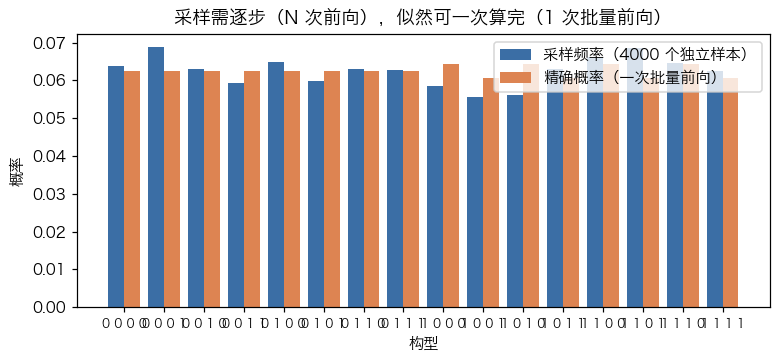

In [8]:
def sample_ar(made, rng, n_samples):
    """自回归采样：必须一位一位生成，共 N 次前向。"""
    x = jnp.zeros((n_samples, N))
    for i in range(N):
        logits = made_logits(made, x)[:, i]      # 前缀已填好，直接取第 i 个输出
        rng, sub = jax.random.split(rng)
        bits = jax.random.bernoulli(sub, jax.nn.sigmoid(logits)).astype(x.dtype)
        x = x.at[:, i].set(bits)
    return x

rng, key = jax.random.split(key)
samples = np.asarray(sample_ar(made, rng, 4000))

# 经验频率 vs 精确概率（16 个构型）
hits = (samples[:, None, :] == configs[None, :, :]).all(axis=-1)   # (4000, 16)
emp = hits.mean(axis=0)

print("构型        采样频率    精确概率")
for c, e, p in zip(configs, emp, probs):
    print(" ".join(map(str, c)), "     ", f"{e:.4f}      {float(p):.4f}")

xpos = np.arange(len(configs))
fig, ax = plt.subplots(figsize=(7.2, 3.4), dpi=110)
ax.bar(xpos - 0.2, emp, width=0.4, color="#3b6ea5", label="采样频率（4000 个独立样本）")
ax.bar(xpos + 0.2, np.asarray(probs), width=0.4, color="#dd8452", label="精确概率（一次批量前向）")
ax.set_xticks(xpos)
ax.set_xticklabels([" ".join(map(str, c)) for c in configs], fontsize=8)
ax.set_xlabel("构型")
ax.set_ylabel("概率")
ax.set_title("采样需逐步（N 次前向），似然可一次算完（1 次批量前向）")
ax.legend()
plt.tight_layout()
plt.show()

采样频率与精确概率在统计误差内吻合（$\propto 1/\sqrt{M}$），而且这些样本是**严格独立**的——没有 burn-in、没有自相关，这是自回归结构送给蒙特卡洛的又一份礼物（NetKet 里对应的正是 `ARDirectSampler`，见 05 课）。

## 7 · 本课小结

> **掩码 = 结构性归一化**：把"只许看过去"的因果约定焊进连接方式，网络从出生起就是合法分布，训练只负责调数值。

| 性质 | 代价 |
|---|---|
| 算似然 $\log p(x)$（可批量） | **1 次前向**（16 个构型一次算完，大 $N$ 同样） |
| 采样新构型 | **必须逐步**：$N$ 次前向，一位一位接龙 |
| 归一化 | 免 $Z$，自动成立 |
| 因果序 | 可任意设计/置换（MADE 的随机换序技巧） |

**类比升级**：上节课的逐字接龙要"写一个字、问一次网络"；这节课的 MADE 是一张**涂黑了未来答案区的答题卡**——一次填出所有空格的条件答案；但真要"写文章"（采样）时，还是得按顺序一格一格誊写。

**下一课预告**：怎么训练？（教师强制 + 逐位交叉熵：目标条件分布当下即可得，不需要配分函数）；以及如何把自回归网络接进 NetKet 的 VMC 流程，用 $\log p$ 直接构造变分能量（见 04、05 课）。